# CellScope — Phase 1

**End-to-End Medical Image Analysis for Nuclei Instance Segmentation and Cell-Level Morphological Quantification.**

### Complete Notebook:
- **Dataset** `data-science-bowl-2018.zip`from kaggle
- **Automated Extraction & Preprocessing:** Unpacks raw zip files, extracts `stage1_train`, merges multi-mask annotations into single-channel `uint16` instance label maps, and splits `stage1_train` into **70% Train / 15% Validation / 15% Test**.
- **PyTorch Dataset & Augmentations:** Random flips, rotations, brightness/contrast jitter, and ImageNet standardization.
- **Vanilla U-Net Architecture:** 4 downsampling blocks, bottleneck, 4 upsampling blocks with skip connections.
- **Combined BCE + Dice Loss:** Addresses class imbalance and optimizes cell boundary overlap.
- **Training with LR Scheduler:** AdamW + `ReduceLROnPlateau` monitoring validation Dice score.
- **Classical Post-Processing & Quantification:** Euclidean distance transform + regional peak detection + marker-controlled watershed segmentation, extracting cell-level features (area, perimeter, circularity, eccentricity, centroid, density, spatial nearest-neighbor clustering via `cKDTree`).
- **Rigorous Evaluation:** Pixel metrics (Dice, IoU) and matched-instance detection F1 @ IoU 0.5 via Hungarian matching.
- **Qualitative Visualizer & Export:** Generates side-by-side diagnostic figures and prepares `models/unet_nuclei_best.pt` for Phase 2.

---
## 1. Environment & GPU Verification

In [1]:
!pip install -q opencv-python-headless scipy pandas matplotlib tqdm

In [2]:
import os
import sys
import time
import math
import glob
import json
import shutil
import zipfile
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional, Union

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from scipy.spatial import cKDTree
from scipy.optimize import linear_sum_assignment

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using PyTorch version: {torch.__version__}")
print(f"Compute Device: {device}")
if device.type == 'cuda':
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    !nvidia-smi

Using PyTorch version: 2.11.0+cu128
Compute Device: cuda
GPU Model: Tesla T4
Wed Sep 16 20:00:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                    

---
## 2. Dataset Acquisition: Upload or Locate `data-science-bowl-2018.zip`



In [3]:
DATA_DIR = Path('data')
RAW_DIR = DATA_DIR / 'raw' / 'dsb2018'
PROCESSED_DIR = DATA_DIR / 'processed'
SPLITS_DIR = DATA_DIR / 'splits'
MODELS_DIR = Path('models')
RESULTS_DIR = Path('results')

for d in [RAW_DIR, PROCESSED_DIR, SPLITS_DIR, MODELS_DIR, RESULTS_DIR, RESULTS_DIR / 'qualitative']:
    d.mkdir(parents=True, exist_ok=True)

zips = (list(Path('.').glob('*data-science-bowl-2018*.zip')))

zip_to_extract = None
if zips:
    zip_to_extract = zips[0]
    print(f"Found dataset zip file: {zip_to_extract}")
else:
    print("No existing data-science-bowl-2018.zip found in working directory.")
    # If running on Google Colab, allow interactive upload
    try:
        from google.colab import files
        print("\n--- Please upload your data-science-bowl-2018.zip file ---")
        uploaded = files.upload()
        for fname in uploaded.keys():
            if fname.endswith('.zip'):
                zip_to_extract = Path(fname)
                break
    except ImportError:
        print("Interactive upload is only available in Google Colab.")
        print("Please place data-science-bowl-2018.zip into the current directory and re-run this cell.")

Found dataset zip file: data-science-bowl-2018.zip


---
## 3. Data Unpacking, Instance Mask Merging & Train/Val/Test Splitting

1. Unpacks `data-science-bowl-2018.zip` and nested `stage1_train.zip`.
2. Merges all individual binary masks per image into a single-channel `uint16` label mask where each cell has a distinct ID ($1 \dots N$, background = 0).
3. Splits `stage1_train` into **70% Train / 15% Val / 15% Test**.

In [4]:
# Extract main zip archive if located
if zip_to_extract and zip_to_extract.exists():
    print(f"Extracting {zip_to_extract} to {RAW_DIR}...")
    with zipfile.ZipFile(zip_to_extract, 'r') as zf:
        zf.extractall(RAW_DIR)

# Check for nested stage1_train.zip
nested_train_zip = RAW_DIR / 'stage1_train.zip'
if nested_train_zip.exists() and not (RAW_DIR / 'stage1_train').exists():
    print("Extracting nested stage1_train.zip...")
    with zipfile.ZipFile(nested_train_zip, 'r') as zf:
        zf.extractall(RAW_DIR / 'stage1_train')

# Verify stage1_train exists
stage1_train_dir = RAW_DIR / 'stage1_train'
if not stage1_train_dir.exists():
    if list(RAW_DIR.glob('*/images')):
        stage1_train_dir = RAW_DIR

print(f"Locating sample directories in {stage1_train_dir}...")
sample_dirs = [d for d in stage1_train_dir.iterdir() if d.is_dir() and (d / 'images').exists()]
print(f"Found {len(sample_dirs)} total samples in stage1_train.")

# Preprocess and merge individual instance masks
valid_image_ids = []
for s_dir in tqdm(sample_dirs, desc="Merging Instance Masks"):
    img_id = s_dir.name
    img_files = list((s_dir / 'images').glob('*.png'))
    if not img_files:
        continue

    img_path = img_files[0]
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    h, w = img.shape[:2]
    # uint16 label mask (0 = background, 1..N = distinct nuclei IDs)
    merged_mask = np.zeros((h, w), dtype=np.uint16)

    masks_dir = s_dir / 'masks'
    if masks_dir.exists():
        mask_files = sorted(list(masks_dir.glob('*.png')))
        for inst_id, m_file in enumerate(mask_files, start=1):
            single_m = cv2.imread(str(m_file), cv2.IMREAD_GRAYSCALE)
            if single_m is not None:
                merged_mask[single_m > 0] = inst_id

    target_img_path = PROCESSED_DIR / f"{img_id}.png"
    target_mask_path = PROCESSED_DIR / f"{img_id}_mask.png"

    cv2.imwrite(str(target_img_path), img)
    cv2.imwrite(str(target_mask_path), merged_mask)
    valid_image_ids.append(img_id)

print(f"\nSuccessfully preprocessed {len(valid_image_ids)} images into {PROCESSED_DIR}.")

# Create reproducible 70 / 15 / 15 Train / Val / Test split
np.random.seed(42)
shuffled_ids = np.random.permutation(sorted(valid_image_ids))
n_total = len(shuffled_ids)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)

train_ids = shuffled_ids[:n_train].tolist()
val_ids = shuffled_ids[n_train:n_train + n_val].tolist()
test_ids = shuffled_ids[n_train + n_val:].tolist()

for split_name, s_ids in [('train', train_ids), ('val', val_ids), ('test', test_ids)]:
    with open(SPLITS_DIR / f"{split_name}.txt", 'w') as f:
        for item in s_ids:
            f.write(f"{item}\n")

print(f"Partitioned stage1_train into: Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")
print(f"Manifests saved to {SPLITS_DIR}")

Extracting data-science-bowl-2018.zip to data/raw/dsb2018...
Extracting nested stage1_train.zip...
Locating sample directories in data/raw/dsb2018/stage1_train...
Found 670 total samples in stage1_train.


Merging Instance Masks:   0%|          | 0/670 [00:00<?, ?it/s]


Successfully preprocessed 670 images into data/processed.
Partitioned stage1_train into: Train: 468 | Val: 100 | Test: 102
Manifests saved to data/splits


---
## 4. PyTorch Dataset & Augmentation Engine

- Collapses instance IDs into binary foreground maps `{0.0, 1.0}` for semantic U-Net training.
- Normalizes images using ImageNet mean/std to stabilize gradients across varied staining modalities.
- Training augmentations: Random horizontal/vertical flips, 90° rotations, brightness/contrast jitter, random cropping/resizing to $256 \times 256$.

In [5]:
class NucleiDataset(Dataset):
    def __init__(self, processed_dir: Path, split_file: Path, is_train: bool = True, img_size: Tuple[int, int] = (256, 256)):
        self.processed_dir = Path(processed_dir)
        self.is_train = is_train
        self.img_size = img_size

        with open(split_file, 'r') as f:
            self.image_ids = [line.strip() for line in f if line.strip()]

        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 1, 3)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 1, 3)

    def __len__(self) -> int:
        return len(self.image_ids)

    def _apply_augmentations(self, img: np.ndarray, mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        target_h, target_w = self.img_size
        if self.is_train:
            if np.random.rand() > 0.5:
                img = np.fliplr(img)
                mask = np.fliplr(mask)
            if np.random.rand() > 0.5:
                img = np.flipud(img)
                mask = np.flipud(mask)
            k = np.random.choice([0, 1, 2, 3])
            if k > 0:
                img = np.rot90(img, k=k)
                mask = np.rot90(mask, k=k)
            if np.random.rand() > 0.5:
                alpha = np.random.uniform(0.85, 1.15)
                beta = np.random.uniform(-15, 15)
                img = np.clip(img.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

            cur_h, cur_w = img.shape[:2]
            if cur_h > target_h and cur_w > target_w:
                top = np.random.randint(0, cur_h - target_h)
                left = np.random.randint(0, cur_w - target_w)
                img = img[top:top + target_h, left:left + target_w]
                mask = mask[top:top + target_h, left:left + target_w]
            else:
                img = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
                mask = cv2.resize(mask, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
        else:
            cur_h, cur_w = img.shape[:2]
            if cur_h >= target_h and cur_w >= target_w:
                top = (cur_h - target_h) // 2
                left = (cur_w - target_w) // 2
                img = img[top:top + target_h, left:left + target_w]
                mask = mask[top:top + target_h, left:left + target_w]
            else:
                img = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
                mask = cv2.resize(mask, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
        return img, mask

    def __getitem__(self, idx: int):
        img_id = self.image_ids[idx]
        bgr = cv2.imread(str(self.processed_dir / f"{img_id}.png"))
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        mask_path = self.processed_dir / f"{img_id}_mask.png"
        inst_mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
        if inst_mask is None:
            inst_mask = np.zeros(rgb.shape[:2], dtype=np.uint16)

        rgb_aug, inst_aug = self._apply_augmentations(rgb, inst_mask)
        bin_mask = (inst_aug > 0).astype(np.float32)

        norm_img = (rgb_aug.astype(np.float32) / 255.0 - self.mean) / self.std
        img_tensor = torch.from_numpy(np.transpose(norm_img, (2, 0, 1)).astype(np.float32))
        mask_tensor = torch.from_numpy(np.expand_dims(bin_mask, axis=0).astype(np.float32))
        return img_tensor, mask_tensor

# Create DataLoaders
train_ds = NucleiDataset(PROCESSED_DIR, SPLITS_DIR / 'train.txt', is_train=True)
val_ds = NucleiDataset(PROCESSED_DIR, SPLITS_DIR / 'val.txt', is_train=False)
test_ds = NucleiDataset(PROCESSED_DIR, SPLITS_DIR / 'test.txt', is_train=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

# Batch shape sanity check
sample_imgs, sample_masks = next(iter(train_loader))
print(f"Loaded batch of images: {sample_imgs.shape} | masks: {sample_masks.shape}")
assert sample_imgs.shape == (16, 3, 256, 256)
assert sample_masks.shape == (16, 1, 256, 256)
print("DataLoader verification PASSED!")

Loaded batch of images: torch.Size([16, 3, 256, 256]) | masks: torch.Size([16, 1, 256, 256])
DataLoader verification PASSED!


---
## 5. Vanilla U-Net Architecture & BCE + Dice Loss

In [6]:

# U-Net Model, Loss Functions & Metrics

from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        mid_channels: Optional[int] = None
    ):
        super().__init__()

        if mid_channels is None:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                mid_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                mid_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.double_conv(x)


# Downsampling Block
class Down(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.maxpool_conv(x)


# Upsampling Block
class Up(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        bilinear: bool = True
    ):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(
                scale_factor=2,
                mode="bilinear",
                align_corners=True
            )

            self.conv = DoubleConv(
                in_channels,
                out_channels,
                in_channels // 2
            )

        else:
            self.up = nn.ConvTranspose2d(
                in_channels,
                in_channels // 2,
                kernel_size=2,
                stride=2
            )

            self.conv = DoubleConv(
                in_channels,
                out_channels
            )

    def forward(
        self,
        x1: torch.Tensor,
        x2: torch.Tensor
    ) -> torch.Tensor:

        # Upsample decoder feature map
        x1 = self.up(x1)

        # Handle any spatial-size mismatch
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        if diff_y != 0 or diff_x != 0:
            x1 = F.pad(
                x1,
                [
                    diff_x // 2,
                    diff_x - diff_x // 2,
                    diff_y // 2,
                    diff_y - diff_y // 2
                ]
            )

        # Skip connection
        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)


# U-Net
class UNet(nn.Module):
    def __init__(
        self,
        n_channels: int = 3,
        n_classes: int = 1,
        bilinear: bool = True
    ):
        super().__init__()

        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        # Encoder
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)

        # Reduce bottleneck channels when using bilinear upsampling
        factor = 2 if bilinear else 1

        self.down4 = Down(512, 1024 // factor)

        # Decoder
        self.up1 = Up(
            1024,
            512 // factor,
            bilinear
        )

        self.up2 = Up(
            512,
            256 // factor,
            bilinear
        )

        self.up3 = Up(
            256,
            128 // factor,
            bilinear
        )

        self.up4 = Up(
            128,
            64,
            bilinear
        )

        self.outc = nn.Conv2d(
            64,
            n_classes,
            kernel_size=1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Decoder + skip connections
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        # Logits
        logits = self.outc(x)

        return logits


# Dice Loss
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(
        self,
        pred: torch.Tensor,
        target: torch.Tensor
    ) -> torch.Tensor:

        pred = torch.sigmoid(pred)
        p_flat = pred.contiguous().view(pred.size(0), -1)
        t_flat = target.contiguous().view(target.size(0), -1)
        intersection = (p_flat * t_flat).sum(dim=1)
        cardinality = (
            p_flat.sum(dim=1)
            + t_flat.sum(dim=1)
        )
        dice = (
            2.0 * intersection + self.smooth
        ) / (
            cardinality + self.smooth
        )
        return 1.0 - dice.mean()

# Combined BCE + Dice Loss
class BCEDiceLoss(nn.Module):
    def __init__(
        self,
        bce_weight: float = 0.5,
        dice_weight: float = 0.5
    ):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(
        self,
        pred: torch.Tensor,
        target: torch.Tensor
    ) -> torch.Tensor:

        bce_loss = self.bce(pred, target)
        dice_loss = self.dice(pred, target)

        total_loss = (
            self.bce_weight * bce_loss
            + self.dice_weight * dice_loss
        )

        return total_loss


# Dice Score
def dice_score(
    pred: torch.Tensor,
    target: torch.Tensor,
    thresh: float = 0.5
) -> float:

    pred = torch.sigmoid(pred)
    p = (pred > thresh).float().view(pred.size(0), -1)

    t = (target > thresh).float().view(target.size(0), -1)

    intersection = (p * t).sum(dim=1)
    cardinality = (
        p.sum(dim=1)+ t.sum(dim=1)
    )

    dice = (2.0 * intersection + 1e-6) / (cardinality + 1e-6)

    return dice.mean().item()

# IoU Score
def iou_score(
    pred: torch.Tensor,
    target: torch.Tensor,
    thresh: float = 0.5
) -> float:


    pred = torch.sigmoid(pred)
    p = (pred > thresh).float().view(pred.size(0), -1)

    t = (target > thresh).float().view(target.size(0), -1)

    # Intersection
    intersection = (p * t).sum(dim=1)

    # Union
    union = (
        p.sum(dim=1)
        + t.sum(dim=1)
        - intersection
    )

    iou = ( intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()


# Initialize Model
model = UNet(
    n_channels=3,
    n_classes=1,
    bilinear=True
).to(device)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"UNet initialized with "
    f"{trainable_params:,} trainable parameters."
)
print(f"Device: {device}")

UNet initialized with 17,262,977 trainable parameters.
Device: cuda


---
## 6. Training Loop with `ReduceLROnPlateau` & CSV Logging



In [7]:
#  U-Net Training

import time
import pandas as pd
import torch

from torch.optim.lr_scheduler import ReduceLROnPlateau


# Training Configuration

EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-4

criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=4
)


use_amp = device.type == "cuda"

scaler = (
    torch.amp.GradScaler("cuda")
    if use_amp
    else None
)


history = []

best_val_dice = -1.0

best_checkpoint_path = (
    MODELS_DIR / "unet_nuclei_best.pt"
)

print(
    f"Beginning training for "
    f"{EPOCHS} epochs on {device}..."
)

start_train_time = time.time()


# TRAINING LOOP

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    model.train()

    train_loss = 0.0
    train_dice = 0.0
    train_iou = 0.0

    for imgs, masks in train_loader:

        # Move tensors to GPU
        imgs = imgs.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        # Make sure target is float
        masks = masks.float()

        # Clear gradients
        optimizer.zero_grad(
            set_to_none=True
        )

        # Mixed Precision Training
        if use_amp:

            with torch.amp.autocast(
                device_type="cuda"
            ):

                # Forward pass
                preds = model(imgs)

                # BCEWithLogits + Dice
                loss = criterion(
                    preds,
                    masks
                )

            # Backpropagation with GradScaler
            scaler.scale(loss).backward()

            scaler.step(optimizer)

            scaler.update()

        else:

            # Normal FP32 training
            preds = model(imgs)

            loss = criterion(
                preds,
                masks
            )

            loss.backward()

            optimizer.step()

        # Accumulate training metrics
        train_loss += loss.item()

        train_dice += dice_score(
            preds.detach(),
            masks
        )

        train_iou += iou_score(
            preds.detach(),
            masks
        )

    # Average training metrics
    train_loss /= len(train_loader)
    train_dice /= len(train_loader)
    train_iou /= len(train_loader)



    # VALIDATION

    model.eval()

    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():

        for imgs, masks in val_loader:

            imgs = imgs.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            masks = masks.float()

            # AMP can also be used during validation
            if use_amp:

                with torch.amp.autocast(
                    device_type="cuda"
                ):
                    preds = model(imgs)

                    loss = criterion(
                        preds,
                        masks
                    )

            else:

                preds = model(imgs)

                loss = criterion(
                    preds,
                    masks
                )

            # Accumulate validation metrics
            val_loss += loss.item()

            val_dice += dice_score(
                preds,
                masks
            )

            val_iou += iou_score(
                preds,
                masks
            )

    # Average validation metrics
    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    scheduler.step(val_dice)

    is_best = val_dice > best_val_dice

    if is_best:

        best_val_dice = val_dice

        torch.save(
            model.state_dict(),
            str(best_checkpoint_path)
        )

        status_str = "[BEST CHECKPOINT SAVED]"

    else:

        status_str = ""

    duration = time.time() - epoch_start

    current_lr = optimizer.param_groups[0]["lr"]

    history.append(
        {
            "epoch": epoch,

            "train_loss": train_loss,
            "train_dice": train_dice,
            "train_iou": train_iou,

            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou,

            "learning_rate": current_lr,
            "duration_sec": duration
        }
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS:02d} | "
        f"Train Loss: {train_loss:.4f}, "
        f"Dice: {train_dice:.4f}, "
        f"IoU: {train_iou:.4f} | "
        f"Val Loss: {val_loss:.4f}, "
        f"Dice: {val_dice:.4f}, "
        f"IoU: {val_iou:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"{duration:.1f}s "
        f"{status_str}"
    )


history_df = pd.DataFrame(history)

history_df.to_csv(
    str(RESULTS_DIR / "train_log.csv"),
    index=False
)

total_training_time = (
    time.time() - start_train_time
) / 60.0

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    f"Total training time: "
    f"{total_training_time:.2f} minutes"
)

print(
    f"Best validation Dice: "
    f"{best_val_dice:.4f}"
)

print(
    f"Best checkpoint: "
    f"{best_checkpoint_path}"
)

Beginning training for 50 epochs on cuda...
Epoch 01/50 | Train Loss: 0.6433, Dice: 0.5171, IoU: 0.3899 | Val Loss: 0.8131, Dice: 0.3520, IoU: 0.2411 | LR: 1.00e-04 | 13.8s [BEST CHECKPOINT SAVED]
Epoch 02/50 | Train Loss: 0.5315, Dice: 0.7202, IoU: 0.5965 | Val Loss: 0.4778, Dice: 0.7775, IoU: 0.6616 | LR: 1.00e-04 | 11.8s [BEST CHECKPOINT SAVED]
Epoch 03/50 | Train Loss: 0.5008, Dice: 0.7767, IoU: 0.6627 | Val Loss: 0.4477, Dice: 0.8512, IoU: 0.7582 | LR: 1.00e-04 | 11.7s [BEST CHECKPOINT SAVED]
Epoch 04/50 | Train Loss: 0.4794, Dice: 0.8061, IoU: 0.6984 | Val Loss: 0.4502, Dice: 0.8236, IoU: 0.7219 | LR: 1.00e-04 | 11.5s 
Epoch 05/50 | Train Loss: 0.4620, Dice: 0.8265, IoU: 0.7257 | Val Loss: 0.4223, Dice: 0.8406, IoU: 0.7448 | LR: 1.00e-04 | 11.5s 
Epoch 06/50 | Train Loss: 0.4510, Dice: 0.8233, IoU: 0.7258 | Val Loss: 0.3979, Dice: 0.8601, IoU: 0.7694 | LR: 1.00e-04 | 12.0s [BEST CHECKPOINT SAVED]
Epoch 07/50 | Train Loss: 0.4416, Dice: 0.8287, IoU: 0.7316 | Val Loss: 0.3900, Dice

### Plot Training Dynamics

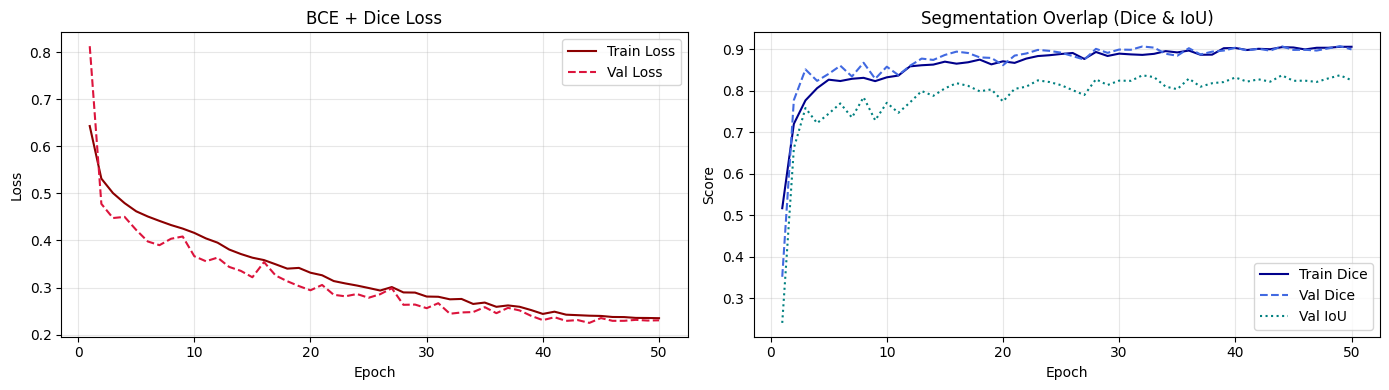

In [8]:
df_log = pd.DataFrame(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(df_log['epoch'], df_log['train_loss'], label='Train Loss', color='darkred')
ax1.plot(df_log['epoch'], df_log['val_loss'], label='Val Loss', color='crimson', linestyle='--')
ax1.set_title('BCE + Dice Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df_log['epoch'], df_log['train_dice'], label='Train Dice', color='darkblue')
ax2.plot(df_log['epoch'], df_log['val_dice'], label='Val Dice', color='royalblue', linestyle='--')
ax2.plot(df_log['epoch'], df_log['val_iou'], label='Val IoU', color='teal', linestyle=':')
ax2.set_title('Segmentation Overlap (Dice & IoU)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'training_curves.png'), dpi=150)
plt.show()

---
## 7. Classical Post-Processing & Morphological Quantification

Converts raw continuous U-Net probability maps into separated instances via marker-controlled watershed, extracting cell-level features (`area`, `perimeter`, `circularity`, `eccentricity`, `centroid`) and spatial clustering via `scipy.spatial.cKDTree`.

In [9]:
class NucleiPostProcessor:
    def __init__(self, prob_threshold: float = 0.5, min_distance_factor: float = 0.35, min_nucleus_area: int = 15, pixel_scale_um: float = 0.25):
        self.prob_threshold = prob_threshold
        self.min_distance_factor = min_distance_factor
        self.min_nucleus_area = min_nucleus_area
        self.pixel_scale_um = pixel_scale_um

    def separate_instances(self, prob_map: np.ndarray, rgb_image: Optional[np.ndarray] = None) -> np.ndarray:
        h, w = prob_map.shape[:2]
        binary = (prob_map >= self.prob_threshold).astype(np.uint8) * 255
        kernel_3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_3)

        if np.sum(binary) == 0:
            return np.zeros((h, w), dtype=np.uint16)

        dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
        max_dist = dist.max()
        if max_dist <= 0:
            return np.zeros((h, w), dtype=np.uint16)

        # Peak detection for seeds
        kernel_peak = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
        dilated_dist = cv2.dilate(dist, kernel_peak)
        peak_mask = (dist == dilated_dist) & (dist >= self.min_distance_factor * max_dist) & (dist > 2.0)
        sure_fg = cv2.dilate(peak_mask.astype(np.uint8), cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
        num_markers, markers = cv2.connectedComponents(sure_fg)

        if num_markers <= 1:
            _, sure_fg = cv2.threshold(dist, self.min_distance_factor * max_dist, 255, cv2.THRESH_BINARY)
            num_markers, markers = cv2.connectedComponents(sure_fg.astype(np.uint8))

        sure_bg = cv2.dilate(binary, kernel_3, iterations=3)
        unknown = cv2.subtract(sure_bg, (sure_fg > 0).astype(np.uint8) * 255)
        markers = markers + 1
        markers[unknown == 255] = 0

        if rgb_image is not None and rgb_image.ndim == 3:
            ws_input = rgb_image.copy()
        else:
            dist_norm = cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            ws_input = cv2.cvtColor(255 - dist_norm, cv2.COLOR_GRAY2BGR)

        markers = cv2.watershed(ws_input, markers)
        instance_mask = np.zeros((h, w), dtype=np.uint16)
        instance_mask[markers > 1] = (markers[markers > 1] - 1).astype(np.uint16)
        instance_mask[binary == 0] = 0

        unassigned = (binary > 0) & (instance_mask == 0)
        if np.any(unassigned):
            dilated = cv2.dilate(instance_mask, kernel_3)
            instance_mask[unassigned] = dilated[unassigned]

        compact_mask = np.zeros((h, w), dtype=np.uint16)
        unique_instances = np.unique(instance_mask)
        cur_id = 1
        for inst in unique_instances:
            if inst == 0:
                continue
            inst_region = (instance_mask == inst)
            if np.sum(inst_region) >= self.min_nucleus_area:
                compact_mask[inst_region] = cur_id
                cur_id += 1
        return compact_mask

    def extract_features(self, instance_mask: np.ndarray) -> Tuple[pd.DataFrame, Dict[str, Any]]:
        h, w = instance_mask.shape[:2]
        total_pixels = h * w
        px_area_um2 = self.pixel_scale_um ** 2
        unique_ids = np.unique(instance_mask)
        unique_ids = unique_ids[unique_ids > 0]

        nuclei = []
        centroids = []
        for n_id in unique_ids:
            single_m = (instance_mask == n_id).astype(np.uint8)
            cnts, _ = cv2.findContours(single_m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not cnts:
                continue
            cnt = max(cnts, key=cv2.contourArea)
            area_px = float(np.sum(single_m))
            perim_px = float(cv2.arcLength(cnt, True))
            circ = (4.0 * math.pi * area_px) / (perim_px ** 2) if perim_px > 0 else 0.0
            circ = max(0.0, min(1.0, circ))

            if len(cnt) >= 5:
                try:
                    (cx_e, cy_e), (ax1, ax2), _ = cv2.fitEllipse(cnt)
                    maj, minr = max(ax1, ax2), min(ax1, ax2)
                    ecc = math.sqrt(max(0.0, 1.0 - (minr / maj) ** 2)) if maj > 0 else 0.0
                except Exception:
                    ecc = 0.0
            else:
                ecc = 0.0

            m = cv2.moments(single_m)
            cx = float(m['m10'] / m['m00']) if m['m00'] > 0 else float(cnt[0][0][0])
            cy = float(m['m01'] / m['m00']) if m['m00'] > 0 else float(cnt[0][0][1])
            centroids.append((cx, cy))

            nuclei.append({
                "id": int(n_id), "area": round(area_px, 1), "area_um2": round(area_px * px_area_um2, 2),
                "perimeter": round(perim_px, 1), "perimeter_um": round(perim_px * self.pixel_scale_um, 2),
                "circularity": round(circ, 4), "eccentricity": round(ecc, 4),
                "centroid": [round(cx, 1), round(cy, 1)]
            })

        df = pd.DataFrame(nuclei)
        count = len(nuclei)
        summary = {
            "nucleus_count": count,
            "density_per_mm2": round((count / ((total_pixels * px_area_um2) / 1e6)), 2) if total_pixels > 0 else 0.0,
            "mean_area": round(float(df['area'].mean()), 2) if not df.empty else 0.0,
            "mean_circularity": round(float(df['circularity'].mean()), 4) if not df.empty else 0.0,
            "mean_eccentricity": round(float(df['eccentricity'].mean()), 4) if not df.empty else 0.0,
            "pixel_scale_assumed_um": self.pixel_scale_um
        }
        if count >= 2:
            dists, _ = cKDTree(centroids).query(centroids, k=2)
            summary["mean_nearest_neighbor_distance_um"] = round(float(np.mean(dists[:, 1] * self.pixel_scale_um)), 2)
        else:
            summary["mean_nearest_neighbor_distance_um"] = None
        return df, summary

    def render_overlay(self, rgb_image: np.ndarray, instance_mask: np.ndarray) -> np.ndarray:
        h, w = instance_mask.shape[:2]
        if rgb_image.shape[:2] != (h, w):
            rgb_image = cv2.resize(rgb_image, (w, h))
        color_mask = np.zeros((h, w, 3), dtype=np.uint8)
        contours_layer = np.zeros((h, w, 3), dtype=np.uint8)
        unique_ids = np.unique(instance_mask)
        unique_ids = unique_ids[unique_ids > 0]

        np.random.seed(1337)
        palette = np.random.randint(60, 255, size=(len(unique_ids) + 1, 3), dtype=np.uint8)
        for idx, n_id in enumerate(unique_ids):
            m = (instance_mask == n_id).astype(np.uint8)
            color_mask[m > 0] = palette[idx].tolist()
            cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(contours_layer, cnts, -1, (255, 255, 255), 1)
            mom = cv2.moments(m)
            if mom["m00"] > 0:
                cv2.circle(contours_layer, (int(mom["m10"]/mom["m00"]), int(mom["m01"]/mom["m00"])), 2, (0, 255, 255), -1)

        fg = (color_mask > 0).any(axis=-1)
        blended = rgb_image.copy()
        blended[fg] = cv2.addWeighted(rgb_image[fg], 0.6, color_mask[fg], 0.4, 0)
        has_c = (contours_layer > 0).any(axis=-1)
        blended[has_c] = contours_layer[has_c]
        return blended

postprocessor = NucleiPostProcessor()
print("NucleiPostProcessor initialized!")

NucleiPostProcessor initialized!


---
## 8. Evaluation on Held-Out Test Split

- **Pixel Metrics:** Dice, IoU (Jaccard), Precision, Recall.
- **Instance Matched F1 Score @ IoU 0.5:** Pairs ground truth nuclei to predicted watershed instances using bipartite matching (Hungarian assignment algorithm). A match is True Positive iff IoU $\ge 0.5$.

In [10]:
# Load best checkpoint for evaluation
eval_model = UNet(n_channels=3, n_classes=1, bilinear=True).to(device)
eval_model.load_state_dict(torch.save if not best_checkpoint_path.exists() else torch.load(str(best_checkpoint_path), map_location=device))
eval_model.eval()

with open(SPLITS_DIR / 'test.txt', 'r') as f:
    test_ids = [line.strip() for line in f if line.strip()]

def compute_matched_instance_f1(gt_inst: np.ndarray, pred_inst: np.ndarray, iou_thresh: float = 0.5):
    gt_ids = np.unique(gt_inst); gt_ids = gt_ids[gt_ids > 0]
    pr_ids = np.unique(pred_inst); pr_ids = pr_ids[pr_ids > 0]
    if len(gt_ids) == 0 and len(pr_ids) == 0:
        return 1.0, 1.0, 1.0
    if len(gt_ids) == 0 or len(pr_ids) == 0:
        return 0.0, 0.0, 0.0

    iou_mat = np.zeros((len(gt_ids), len(pr_ids)), dtype=np.float32)
    for i, g_id in enumerate(gt_ids):
        g_m = (gt_inst == g_id)
        g_a = np.sum(g_m)
        for j, p_id in enumerate(pr_ids):
            p_m = (pred_inst == p_id)
            inter = np.sum(g_m & p_m)
            if inter > 0:
                iou_mat[i, j] = inter / (g_a + np.sum(p_m) - inter)

    r_ind, c_ind = linear_sum_assignment(-iou_mat)
    tp = sum(1 for r, c in zip(r_ind, c_ind) if iou_mat[r, c] >= iou_thresh)
    fp = len(pr_ids) - tp
    fn = len(gt_ids) - tp
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = (2.0 * prec * rec) / (prec + rec + 1e-8)
    return f1, prec, rec

all_pix_dice, all_pix_iou, all_inst_f1 = [], [], []
qual_samples = []

mean_arr = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 1, 3)
std_arr = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 1, 3)

for idx, img_id in enumerate(tqdm(test_ids, desc="Evaluating Test Split")):
    bgr = cv2.imread(str(PROCESSED_DIR / f"{img_id}.png"))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gt_mask = cv2.imread(str(PROCESSED_DIR / f"{img_id}_mask.png"), cv2.IMREAD_UNCHANGED)
    h, w = rgb.shape[:2]

    # Inference
    resized = cv2.resize(rgb, (256, 256))
    norm = (resized.astype(np.float32) / 255.0 - mean_arr) / std_arr
    inp = torch.from_numpy(np.expand_dims(np.transpose(norm, (2, 0, 1)), 0).astype(np.float32)).to(device)

    with torch.no_grad():
        prob_256 = eval_model(inp).squeeze().cpu().numpy()
    prob_map = cv2.resize(prob_256, (w, h))

    pred_instances = postprocessor.separate_instances(prob_map, rgb_image=rgb)
    df_feats, summary = postprocessor.extract_features(pred_instances)
    overlay = postprocessor.render_overlay(rgb, pred_instances)

    # Metrics
    gt_bin = (gt_mask > 0).astype(bool)
    pr_bin = (pred_instances > 0).astype(bool)
    tp = np.sum(gt_bin & pr_bin)
    d_sc = (2.0 * tp) / (np.sum(gt_bin) + np.sum(pr_bin) + 1e-8)
    j_sc = tp / (np.sum(gt_bin | pr_bin) + 1e-8)
    f1, _, _ = compute_matched_instance_f1(gt_mask, pred_instances, iou_thresh=0.5)

    all_pix_dice.append(d_sc)
    all_pix_iou.append(j_sc)
    all_inst_f1.append(f1)

    if len(qual_samples) < 5:
        qual_samples.append((img_id, rgb, gt_mask, prob_map, overlay, d_sc, f1))

print(f"\n================ TEST SPLIT EVALUATION RESULTS ================")
print(f"Samples Evaluated:             {len(test_ids)}")
print(f"Mean Pixel Dice Coefficient:   {np.mean(all_pix_dice):.4f} ± {np.std(all_pix_dice):.4f}")
print(f"Mean Pixel IoU (Jaccard):      {np.mean(all_pix_iou):.4f}")
print(f"Mean Matched Instance F1 @0.5: {np.mean(all_inst_f1):.4f} ± {np.std(all_inst_f1):.4f}")
print(f"===============================================================")

eval_res = {
    "test_samples": len(test_ids),
    "mean_pixel_dice": float(np.mean(all_pix_dice)),
    "mean_pixel_iou": float(np.mean(all_pix_iou)),
    "mean_instance_f1": float(np.mean(all_inst_f1))
}
with open(RESULTS_DIR / 'eval_metrics.json', 'w') as f:
    json.dump(eval_res, f, indent=2)

Evaluating Test Split:   0%|          | 0/102 [00:00<?, ?it/s]


================ TEST SPLIT EVALUATION RESULTS ================
Samples Evaluated:             102
Mean Pixel Dice Coefficient:   0.8686 ± 0.1161
Mean Pixel IoU (Jaccard):      0.7843
Mean Matched Instance F1 @0.5: 0.6820 ± 0.2151


### Display Qualitative Visualizations (5 Side-by-Side Panels)

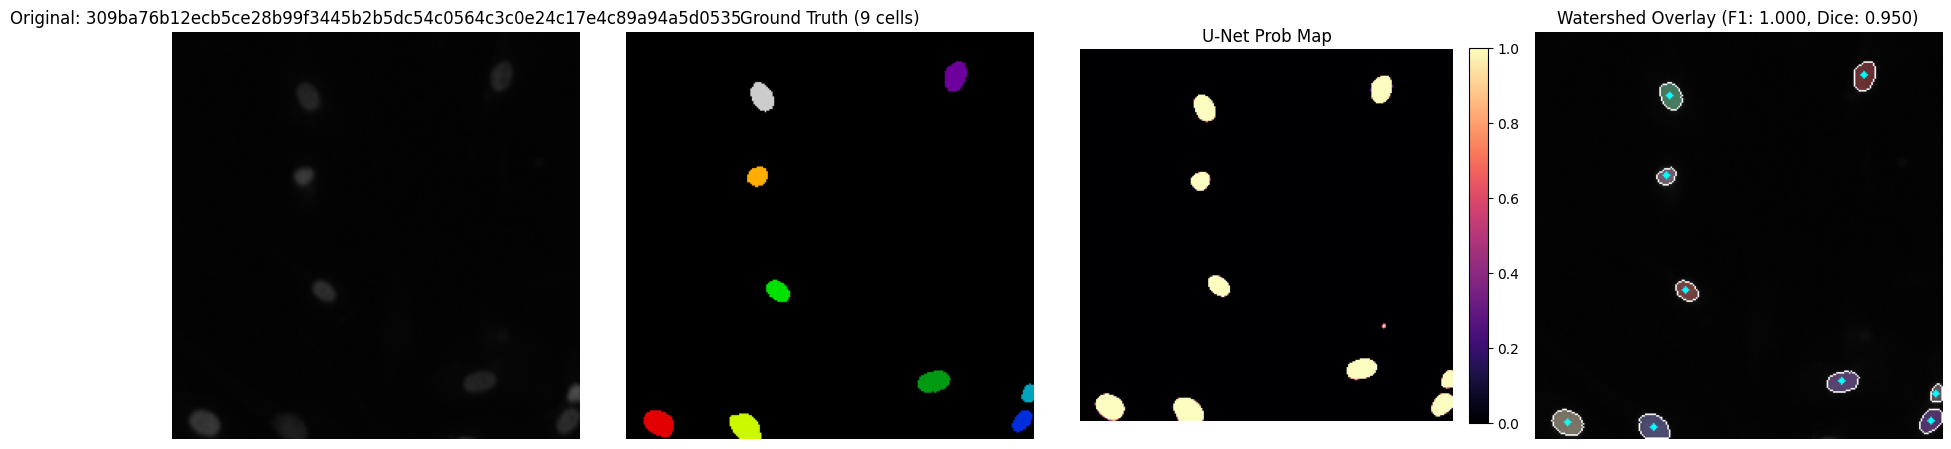

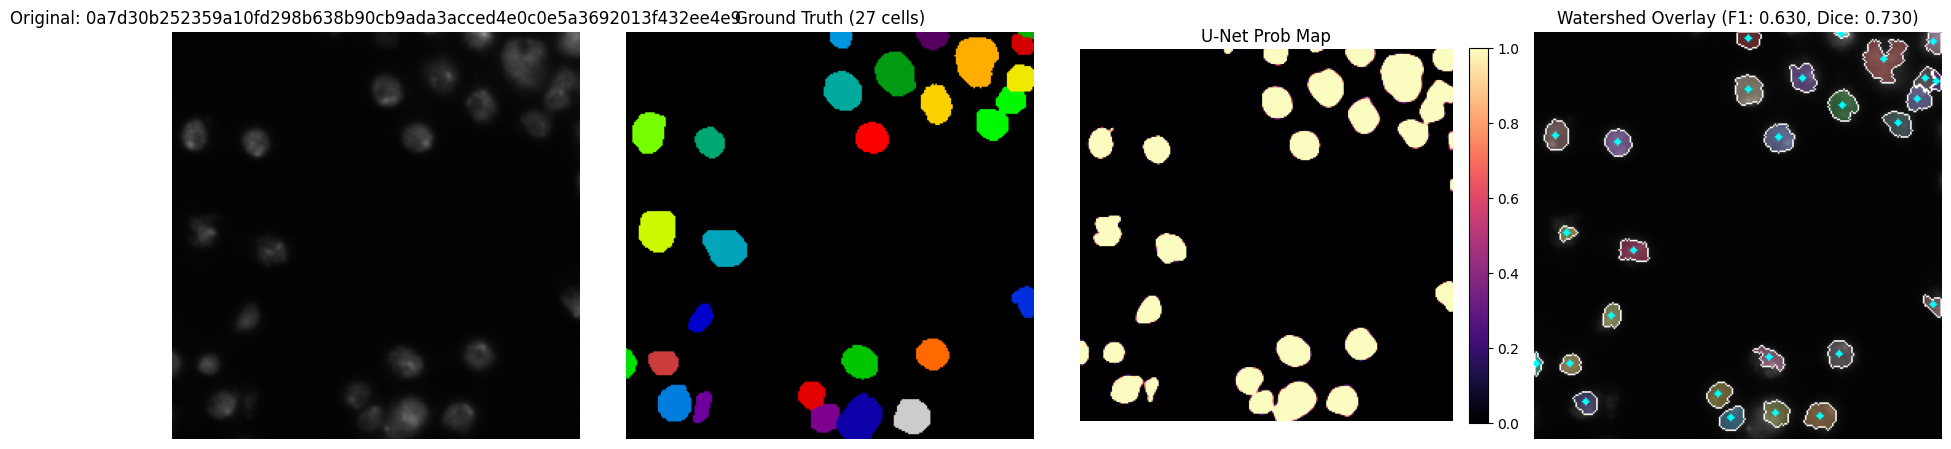

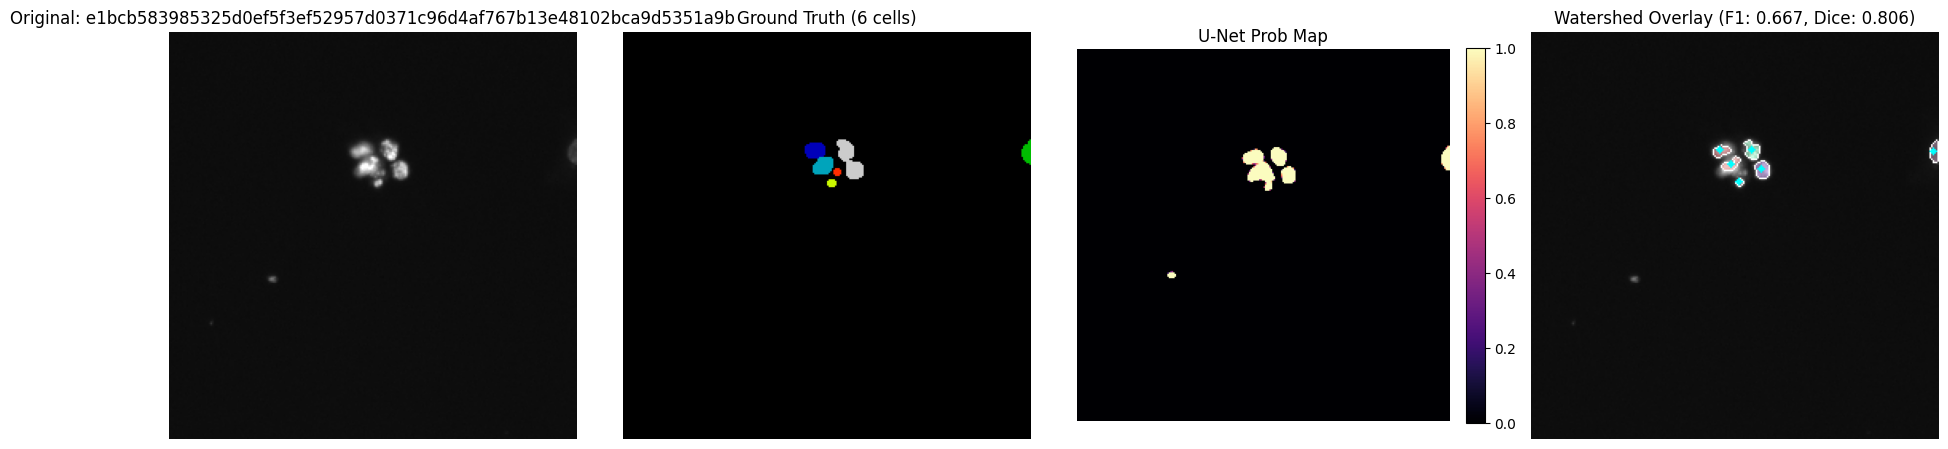

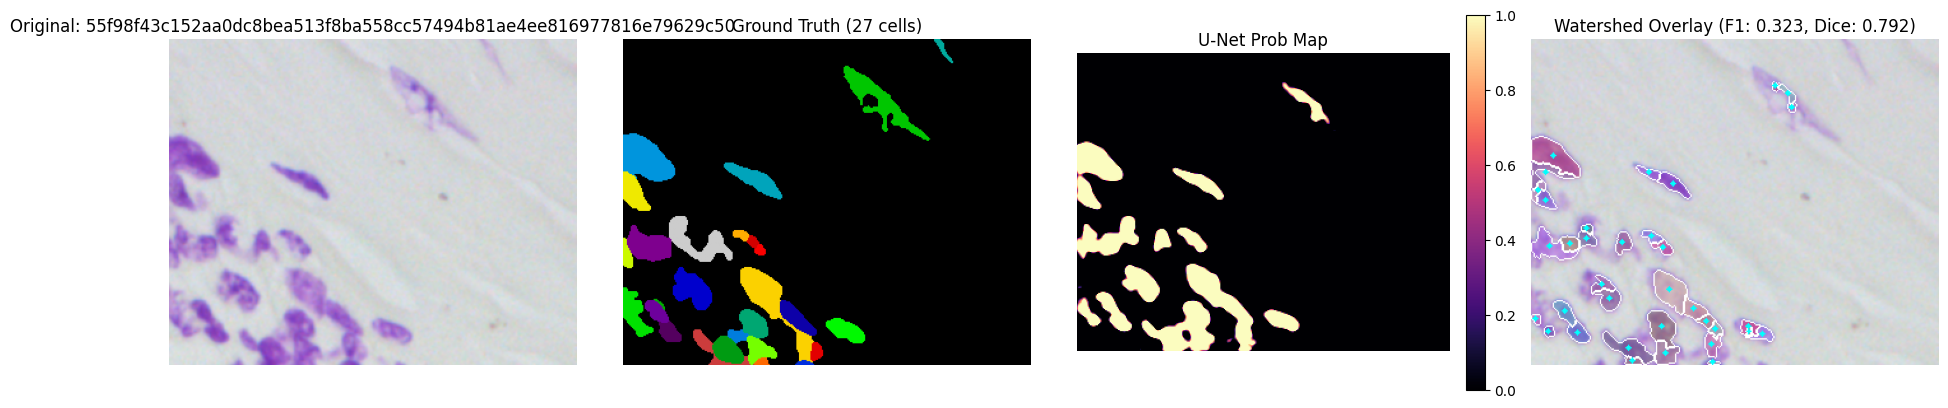

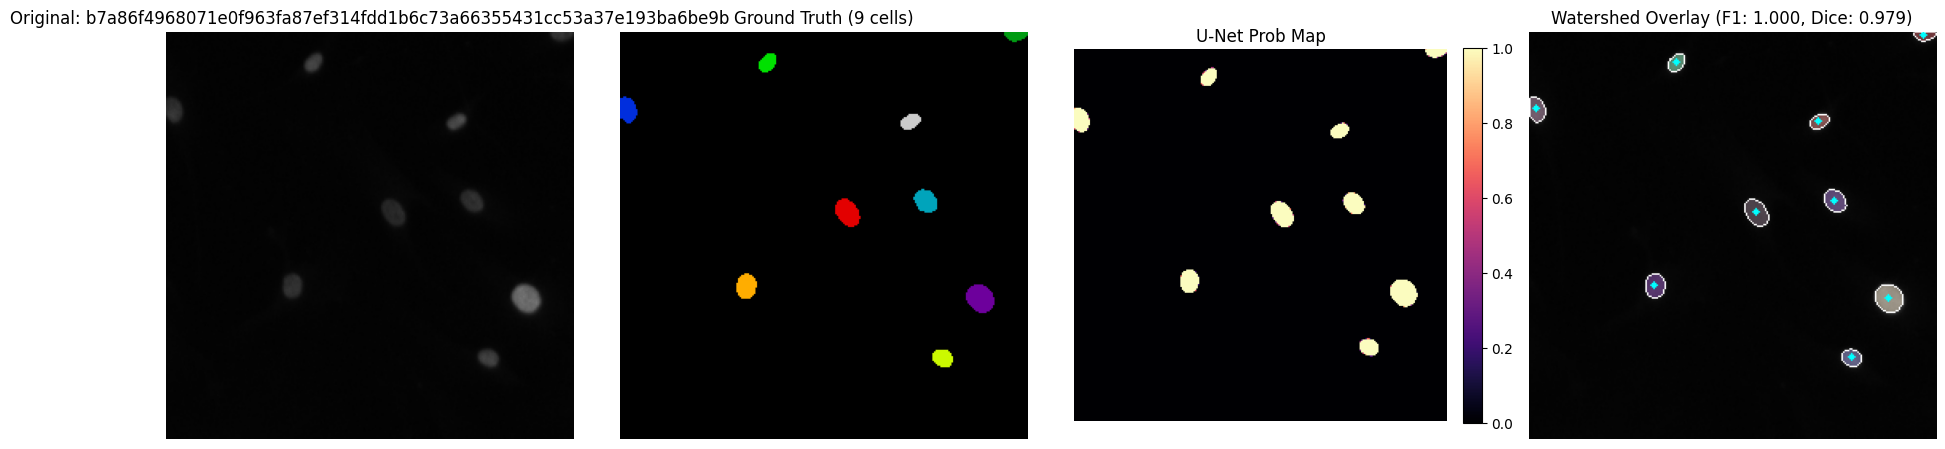

In [11]:
for s_idx, (img_id, rgb, gt, prob, overlay, d_val, f1_val) in enumerate(qual_samples, start=1):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    axes[0].imshow(rgb)
    axes[0].set_title(f"Original: {img_id}")
    axes[0].axis('off')

    axes[1].imshow(gt, cmap='nipy_spectral')
    axes[1].set_title(f"Ground Truth ({len(np.unique(gt))-1} cells)")
    axes[1].axis('off')

    p_im = axes[2].imshow(prob, cmap='magma', vmin=0, vmax=1)
    axes[2].set_title("U-Net Prob Map")
    axes[2].axis('off')
    fig.colorbar(p_im, ax=axes[2], fraction=0.046, pad=0.04)

    axes[3].imshow(overlay)
    axes[3].set_title(f"Watershed Overlay (F1: {f1_val:.3f}, Dice: {d_val:.3f})")
    axes[3].axis('off')

    plt.tight_layout()
    panel_save_path = RESULTS_DIR / 'qualitative' / f"qualitative_panel_{s_idx}_{img_id}.png"
    plt.savefig(str(panel_save_path), dpi=150, bbox_inches='tight')
    plt.show()

---
## 9. Single-Image Inference & Quantification Function




Inference Results for 309ba76b12ecb5ce28b99f3445b2b5dc54c0564c3c0e24c17e4c89a94a5d0535.png:
  Nucleus Count:     9
  Mean Area (px):    185.78
  Mean Circularity:  0.9451
  Mean Eccentricity: 0.7147
  Density (mm^-2):   2197.27


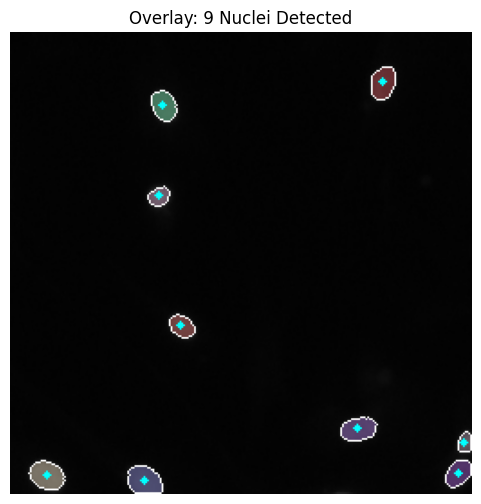

In [12]:
def run_inference(
    image_input: Union[str, Path, np.ndarray],
    model_instance: nn.Module,
    threshold: float = 0.5,
    pixel_scale_um: float = 0.25
) -> Tuple[np.ndarray, List[Dict[str, Any]], Dict[str, Any], np.ndarray]:

    if isinstance(image_input, (str, Path)):
        bgr = cv2.imread(str(image_input))
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    else:
        rgb = image_input.copy()

    orig_h, orig_w = rgb.shape[:2]
    resized = cv2.resize(rgb, (256, 256))
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 1, 3)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 1, 3)
    norm = (resized.astype(np.float32) / 255.0 - mean) / std

    inp = torch.from_numpy(np.expand_dims(np.transpose(norm, (2, 0, 1)), 0).astype(np.float32)).to(device)
    with torch.no_grad():
        prob_256 = model_instance(inp).squeeze().cpu().numpy()
    prob_map = cv2.resize(prob_256, (orig_w, orig_h))

    post = NucleiPostProcessor(prob_threshold=threshold, pixel_scale_um=pixel_scale_um)
    instance_mask = post.separate_instances(prob_map, rgb_image=rgb)
    features_df, summary = post.extract_features(instance_mask)
    overlay = post.render_overlay(rgb, instance_mask)

    return instance_mask, features_df.to_dict(orient='records'), summary, overlay

# Demonstration on first test sample
test_sample_path = PROCESSED_DIR / f"{test_ids[0]}.png"
inst_mask, features, summary, overlay = run_inference(test_sample_path, eval_model)

print(f"\nInference Results for {test_sample_path.name}:")
print(f"  Nucleus Count:     {summary['nucleus_count']}")
print(f"  Mean Area (px):    {summary['mean_area']}")
print(f"  Mean Circularity:  {summary['mean_circularity']}")
print(f"  Mean Eccentricity: {summary['mean_eccentricity']}")
print(f"  Density (mm^-2):   {summary['density_per_mm2']}")

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title(f"Overlay: {summary['nucleus_count']} Nuclei Detected")
plt.axis('off')
plt.show()

---
## 10. Packaging Deliverables for Phase 2

Saves and downloads the trained model checkpoint (`unet_nuclei_best.pt`), evaluation metrics, and reports.

In [13]:
deliverables_zip = 'cellscope_phase1_deliverables.zip'
with zipfile.ZipFile(deliverables_zip, 'w') as zf:
    if best_checkpoint_path.exists():
        zf.write(best_checkpoint_path, arcname='unet_nuclei_best.pt')
    if (RESULTS_DIR / 'eval_metrics.json').exists():
        zf.write(RESULTS_DIR / 'eval_metrics.json', arcname='eval_metrics.json')
    if (RESULTS_DIR / 'train_log.csv').exists():
        zf.write(RESULTS_DIR / 'train_log.csv', arcname='train_log.csv')
    if (RESULTS_DIR / 'training_curves.png').exists():
        zf.write(RESULTS_DIR / 'training_curves.png', arcname='training_curves.png')

print(f"Packaged deliverables into {deliverables_zip}!")

try:
    from google.colab import files
    files.download(deliverables_zip)
    print("Download initiated in your browser.")
except ImportError:
    print(f"File ready on disk: {deliverables_zip}")

Packaged deliverables into cellscope_phase1_deliverables.zip!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated in your browser.
